# Activity 2.1 : Convolutional Neural Network

#### Objective(s):

This activity aims to introduce how to build a convolutional neural network

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to build and train convolutional neural network 
* Evaluate the accuracy and loss of the model using convolutional neural network

#### Resources:
* Jupyter Notebook
* CIFAR-10 dataset

#### Procedures
Load the necessary libraries

In [82]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, preprocessing, models, layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization


import matplotlib.pyplot as plt
%matplotlib inline


* Shuffle the data
* Split the data into train and test sets

In [56]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


Check the image size

In [57]:

x_train[444].shape

(32, 32, 3)

Visualize one of the images

[9]


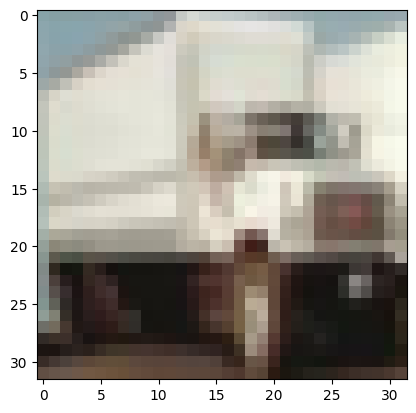

In [58]:
print(y_train[444])
plt.imshow(x_train[444]);

In [59]:
num_classes = 10

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

Instead of classes described by an integer between 0-9 we have a vector with a 1 in the (Pythonic) 9th position

In [60]:
y_train[444]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

Convert to float and scale the datasets

In [61]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

Build a CNN using Keras Sequential

In [62]:

model_1 = Sequential()


## 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, (5, 5), strides = (2,2), padding='same',
                 input_shape=x_train.shape[1:]))
model_1.add(Activation('relu'))

## Another 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, (5, 5), strides = (2,2)))
model_1.add(Activation('relu'))

## 2x2 max pooling reduces to 3 x 3 x 32
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.25))

## Flatten turns 3x3x32 into 288x1
model_1.add(Flatten())
model_1.add(Dense(512))
model_1.add(Activation('relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(num_classes))
model_1.add(Activation('softmax'))

model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,162 (707.66 KB)

 Trainable params: 181,162 (707.66 KB)

 Non-trainable params: 0 (0.00 B)

* Use batch size of 32
* Initiate RMSprop optimizer
* Train the model using RMSprop

In [63]:
batch_size = 32

opt = keras.optimizers.RMSprop(learning_rate=0.0005)


model_1.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model_1.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=15,
              validation_data=(x_test, y_test))

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3489 - loss: 1.7770 - val_accuracy: 0.4595 - val_loss: 1.5113
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4667 - loss: 1.4842 - val_accuracy: 0.5246 - val_loss: 1.3487
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5059 - loss: 1.3886 - val_accuracy: 0.5459 - val_loss: 1.3077
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5296 - loss: 1.3174 - val_accuracy: 0.5667 - val_loss: 1.2333
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5492 - loss: 1.2680 - val_accuracy: 0.5720 - val_loss: 1.1908
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5674 - loss: 1.2266 - val_accuracy: 0.6033 - val_loss: 1.1166
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5801 - loss: 1.1978 - val_accuracy: 0.6120 - val_loss: 1.1012
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5884 - loss: 1

#### Supplementary Activity

* Build a more complicated model with the following pattern:
Conv -> Conv -> MaxPool -> Conv -> Conv -> MaxPool -> (Flatten) -> Dense -> Final Classification

* Use strides of 1 for all convolutional layers.

* Write the number of parameters of your model  and compare it to the previous model

* Train it for 5 epochs. Commpare the training time, loss and accuracy numbers (on both the training and validation sets)?

* Use different structures and run times, and see how accurate your model can be.

In [71]:
# Build a deeper CNN: Conv -> Conv -> MaxPool -> Conv -> Conv -> MaxPool -> Flatten -> Dense -> Output
model_2 = Sequential()
model_2.add(Conv2D(32, (3,3), strides=(1,1), padding='same', activation='relu', input_shape=x_train.shape[1:]))
model_2.add(Conv2D(32, (3,3), strides=(1,1), padding='same', activation='relu'))
model_2.add(MaxPooling2D(pool_size=(2,2)))
model_2.add(Dropout(0.25))

model_2.add(Conv2D(64, (3,3), strides=(1,1), padding='same', activation='relu'))
model_2.add(Conv2D(64, (3,3), strides=(1,1), padding='same', activation='relu'))
model_2.add(MaxPooling2D(pool_size=(2,2)))
model_2.add(Dropout(0.25))

model_2.add(Flatten())
model_2.add(Dense(512, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(num_classes, activation='softmax'))

model_2.summary()

c:\Users\Joshua SD\Documents\CPE313\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Compare parameter counts (model_1 was defined earlier)
print('model_1 params:', model_1.count_params())
print('model_2 params:', model_2.count_params())

model_1 params: 181162
model_2 params: 2168362


In [73]:
# Compile model_2 with the same optimizer settings
opt2 = keras.optimizers.RMSprop(learning_rate=0.0005)
model_2.compile(loss='categorical_crossentropy', optimizer=opt2, metrics=['accuracy'])

# Train for 5 epochs and measure time
start = time.time()
history2 = model_2.fit(x_train, y_train, batch_size=batch_size, epochs=5, validation_data=(x_test, y_test))
duration = time.time() - start
print(f'Training time (s): {duration:.2f}')

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4351 - loss: 1.5629 - val_accuracy: 0.5570 - val_loss: 1.2399
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6030 - loss: 1.1246 - val_accuracy: 0.6599 - val_loss: 0.9588
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.6693 - loss: 0.9454 - val_accuracy: 0.6864 - val_loss: 0.8922
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7052 - loss: 0.8472 - val_accuracy: 0.7025 - val_loss: 0.8565
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.7301 - loss: 0.7812 - val_accuracy: 0.7017 - val_loss: 0.9194
Training time (s): 313.37


In [74]:
# Final metrics from history
train_loss = history2.history['loss'][-1]
train_acc = history2.history.get('accuracy', history2.history.get('acc'))[-1]
val_loss = history2.history['val_loss'][-1]
val_acc = history2.history.get('val_accuracy', history2.history.get('val_acc'))[-1]

print(f'Final training loss: {train_loss:.4f}, acc: {train_acc:.4f}')
print(f'Final validation loss: {val_loss:.4f}, acc: {val_acc:.4f}')

# Simple comparison summary
print('\nComparison:')
print(f'Model_1 params: {model_1.count_params()}')
print(f'Model_2 params: {model_2.count_params()}')


Final training loss: 0.7812, acc: 0.7301
Final validation loss: 0.9194, acc: 0.7017

Comparison:
Model_1 params: 181162
Model_2 params: 2168362


In [101]:
# Use different structures and run times, and see how accurate your model can be
# Build a deeper CNN with 3 conv blocks: Conv -> Conv -> MaxPool repeated 3 times
model_3 = Sequential()

model_3.add(Conv2D(16, (3,3), strides=(1,1), padding='same', activation='relu', input_shape=x_train.shape[1:]))
model_3.add(Conv2D(16, (3,3), strides=(1,1), padding='same', activation='relu'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=(2,2)))
model_3.add(Dropout(0.2))

model_3.add(Conv2D(32, (3,3), strides=(1,1), padding='same', activation='relu', input_shape=x_train.shape[1:]))
model_3.add(Conv2D(32, (3,3), strides=(1,1), padding='same', activation='relu'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=(2,2)))
model_3.add(Dropout(0.25))

model_3.add(Conv2D(128, (3,3), strides=(1,1), padding='same', activation='relu'))
model_3.add(Conv2D(128, (3,3), strides=(1,1), padding='same', activation='relu'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=(2,2)))
model_3.add(Dropout(0.35))

model_3.add(Flatten())
model_3.add(Dense(512, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(num_classes, activation='softmax'))

# Compile model_3 with the same optimizer settings
opt3 = keras.optimizers.Adam(learning_rate=0.00005)
model_3.compile(loss='categorical_crossentropy', optimizer=opt3, metrics=['accuracy'])

# Train for 5 epochs and measure time
start = time.time()
history3 = model_3.fit(x_train, y_train, batch_size=batch_size, epochs=10, validation_data=(x_test, y_test))
duration = time.time() - start
print(f'Training time (s): {duration:.2f}')


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 44ms/step - accuracy: 0.2388 - loss: 2.3052 - val_accuracy: 0.3759 - val_loss: 1.8204
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.3508 - loss: 1.7749 - val_accuracy: 0.4356 - val_loss: 1.6119
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.4077 - loss: 1.6214 - val_accuracy: 0.4729 - val_loss: 1.5164
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.4458 - loss: 1.5226 - val_accuracy: 0.5101 - val_loss: 1.4250
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.4766 - loss: 1.4401 - val_accuracy: 0.5373 - val_loss: 1.3459
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.5011 - loss: 1.3716 - val_accuracy: 0.5633 - val_loss: 1.2764
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.5293 - loss: 1.3084 - val_accuracy: 0.6068 - val_loss: 1.1389
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.5507 -

#### Conclusion

Through this activity I have learned how to create a Convolutional Neural Network(CNN), I also learned how to hypertune the parameters used to create a CNN. During the process I have tried to add more filter from 16, 32, 64, 128, and I've also tried up to 256, wherein I also observed different its changes from 2 filter values only, to 3 or 4. Then I have also changed the stride value 1 and 2; from my research stride is the number of steps (pixels) that we move, wherein here 1 stride is a step-by-step and 2 stride jump every 2 steps. While trying different structures I have also add a few more batch normalization for faster convergence. By the end I have achieved a training accuracy of 0.58 and val accuracy of 0.62 within 10 epochs.